# 📘 **EDA (Exploratory Data Analysis)**
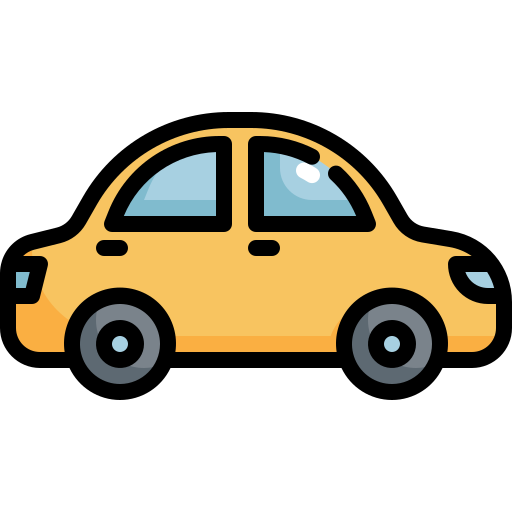

### **📚 Introducció a Machine Learning**  
##### 🗂️ M0572 Sistemes d'aprenentatge automàtic  
###### 👤 *Robert Ventura Vall-llovera*  

---


**Objectiu:** L'objectiu d'aquest Notebook és veure un exemple de Exploració de dades d'un dataset de cotxes d'ocasió. La idea és intentar analitzar els factors que influeixen el el preu dels cotxes.

## 0) Connexió Google Drive

In [157]:
#instal·lació de pandas
#! conda install pandas -y
# pip install pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

drive.mount('/content/drive')
#path = '/content/drive/'
os.chdir('/content/drive/MyDrive/Colab Notebooks/M0572-SistemesAprenentatgeAutomatic/01_introduccio/')
os.getcwd()


sns.set_theme() # Setting seaborn style

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1) Llegim les dades del  Dataset

Aquest dataset conté dades de cotxes usats. Amb q

In [158]:
cars = pd.read_csv('data/venda-cotxes-segona-ma.csv', index_col=None)
#cars = pd.read_csv('data/used_cars_data.csv', index_col=None)
cars.head()

,company,make,model,version,price,price_financed,fuel,year,kms,power,doors,shift,color,photos,is_professional,dealer,phone,province,publish_date,insert_date
0,9881BCDD5A0AD4733037B3FB25E69C3A,KIA,Carnival,KIA Carnival 2.9 CRDi VGT EX 5p.,4860,4860.0,Diésel,2007,221000,185.0,5.0,Manual,Beige (champagne),8,True,VM Motor,928493782,Las Palmas,2020-12-22 13:28:36,2020-12-25 00:00:00
1,9881BCDD5A0AD4733037B3FB25E69C3A,BMW,Serie 5,BMW Serie 5 4p.,1800,NaN,Diésel,2001,205000,NaN,4.0,Manual,Verde,0,False,3F128E570B3A9009D7B52A0523AF43DD,DBB2949B54A306BA299A791B860EEBF6,Tarragona,2020-12-14 07:02:22,2020-12-26 00:00:00
2,9881BCDD5A0AD4733037B3FB25E69C3A,FIAT,500,FIAT 500 1.2 8v 51kW 69CV Lounge 3p.,6490,6490.0,Gasolina,2017,75000,69.0,3.0,Manual,Negro,7,True,LAS PALMAS MOTOR,653895468,Las Palmas,2020-11-20 18:30:00,2020-12-08 00:00:00
3,9881BCDD5A0AD4733037B3FB25E69C3A,OPEL,Astra,OPEL Astra 3p.,5550,NaN,Diésel,2009,137000,NaN,3.0,Manual,Rojo,0,False,22003DEA67E7C5BE6022A29E677668BC,67990DA67E557C1D0C1B6D1DB731938C,Barcelona,2020-11-21 16:37:13,2020-11-24 00:00:00
4,9881BCDD5A0AD4733037B3FB25E69C3A,MERCEDES-BENZ,Clase C,MERCEDES-BENZ Clase C C 220 CDI AVANTGARDE 4p.,11990,11490.0,Diésel,2008,95000,170.0,4.0,Automático,Gris / Plata,21,True,Autos Lipiz,646179040,Madrid,2020-11-05 19:09:27,2020-12-01 00:00:00


In [159]:
cars.tail()

,company,make,model,version,price,price_financed,fuel,year,kms,power,doors,shift,color,photos,is_professional,dealer,phone,province,publish_date,insert_date
4995,9881BCDD5A0AD4733037B3FB25E69C3A,OPEL,Corsa,OPEL Corsa 1.4 66kW 90CV Selective 5p.,10200,9400.0,Gasolina,2018,18318,90.0,5.0,Manual,Blanco (Alpino),32,True,Vara de Quart,689851902,Valencia,2020-11-23 16:24:28,2020-11-26 00:00:00
4996,9881BCDD5A0AD4733037B3FB25E69C3A,TOYOTA,Auris,TOYOTA Auris 1.2 120T Active Touring Sports 5p.,7650,NaN,Gasolina,2016,157000,116.0,5.0,Manual,Azul,5,False,9448B9C35DDD44F451DC88E988CC3A03,67ABDCB290BF2A7CA8D3E84C9007BF9A,Tarragona,2020-11-10 15:27:32,2021-01-10 00:00:00
4997,9881BCDD5A0AD4733037B3FB25E69C3A,PEUGEOT,Partner,PEUGEOT Partner 5p.,6200,NaN,Diésel,2012,125000,NaN,5.0,Manual,Blanco,0,False,92EAF3719159C372F3D50337E0A14F57,A31DAA15140D41FD522BC3DF2341D5A1,Sevilla,2020-10-10 05:51:41,2020-12-16 00:00:00
4998,9881BCDD5A0AD4733037B3FB25E69C3A,MERCEDES-BENZ,GLC Coupé,MERCEDES-BENZ GLC Coupe GLC 220 d 4MATIC 5p.,49900,48000.0,Diésel,2019,15,170.0,5.0,Automático,Gris / Plata,11,True,Autocas Mercedes Benz,964222200,Castellón,2020-11-20 09:43:44,2020-11-28 00:00:00
4999,9881BCDD5A0AD4733037B3FB25E69C3A,MERCEDES-BENZ,Clase SL,MERCEDES-BENZ Clase SL SL 500 2p.,12950,NaN,Gasolina,2003,129000,306.0,2.0,Automático,Negro,30,True,Autofesa,910380569,Madrid,2021-01-19 09:40:55,2021-01-20 00:00:00


Buquem quantes files i columnes tenim

In [160]:
#Veure la dimensió del Dataframe
cars.shape

(5000, 20)

Amb `data.info()` podem veure els tipus de dades que tenim a cada variable així com també si hi han dades nules.

En el cas d'aquest dataset podem veure que tenim les columnes **Mileage, Engine, Poer, Seats, New_price, Price** que contenen valors nulls.


In [161]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   company          5000 non-null   object 
 1   make             5000 non-null   object 
 2   model            4996 non-null   object 
 3   version          5000 non-null   object 
 4   price            5000 non-null   int64  
 5   price_financed   2268 non-null   float64
 6   fuel             4992 non-null   object 
 7   year             5000 non-null   int64  
 8   kms              5000 non-null   int64  
 9   power            4054 non-null   float64
 10  doors            4996 non-null   float64
 11  shift            4990 non-null   object 
 12  color            4942 non-null   object 
 13  photos           5000 non-null   int64  
 14  is_professional  5000 non-null   bool   
 15  dealer           5000 non-null   object 
 16  phone            5000 non-null   object 
 17  province      

## 2) Comprovem duplicats i valors Null

### `duplicated()`

Ens permet obtenir les línies duplicades. Ens retorna una Sèrie per saber si cada fila està duplicada o no. Per defecte utilitza totes les columnes

In [162]:
#Aquest mètode ens retorna una Sèrei de booleans indicant en cada fils si està duplicada o no.
cars.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4995,False
4996,False
4997,False
4998,False


In [163]:
# Mostrem quantes files duplicades hi ha
# Si hi ha només 2 files duplicades el resultat serà 1
print(cars.duplicated().sum())

0


### `drop_duplicates()`

Si volem esborrar files duplicades podem utilitzar aquest mètode. Per defecte, es conserva la primera aparició i s'eliminen les següents.

In [164]:
# Si volem esborrar dupblicats
cars = cars.drop_duplicates()

Si per alun motiu volem esborrar duplicats només tenint en compte un subconjunt de columnes podem utilitzar el paràemtre `subset`.

Si s'utilitza aquest mètodes cal tenir present quina fila conservar. Això ho podem controlar mitjançant:
* `keep='first'` --> Conserva la primera (valor per defecte)
* `keep='last'`  --> Conserva l'última
* `keep='False'` --> Elimina totes les files duplicades.

In [165]:
# En aquest exemple esborrarem tots els cotxes que tinguin l'any i província duplicades.
cars_tmp = cars.drop_duplicates(subset=['year','province'])
cars_tmp.shape

(968, 20)

### `isnull()`

Amb el mètode isnull obtenim la cuantitat de valors NULL de cada columna

In [166]:
#Podem obtenir el número de valors nulls de cada columna.
cars.isnull().sum()

,0
company,0
make,0
model,4
version,0
price,0
price_financed,2732
fuel,8
year,0
kms,0
power,946


In [167]:
# En aquest exemple obtenim el % de dades nulls de cada columna.
(cars.isnull().sum()/(len(cars)))*100

,0
company,0.00
make,0.00
model,0.08
version,0.00
price,0.00
price_financed,54.64
fuel,0.16
year,0.00
kms,0.00
power,18.92


Podem observar que la columna **power** tenim un 18.2% de dades nul·les, que no és poc. I **price_financed** més d'un 50%

Hi ha certes columnes com **model**, **fuel**, **doors** que tenen pocs valors nulls. En aquests casos podem plantejar-nos omplir-los amb valors.

### `fillna()`

Amb aquest mètode podem omplir els valors Null del nostre DataFrame.

In [168]:
# Mitjana
df = cars.copy()
print("Mitjana")
print(df['power'].mean())
df['power'] = df['power'].fillna(df['power'].mean())
print(df['power'].mean())

# Mediana
df = cars.copy()
print("Mediana")
print(df['power'].median())
df['power'] = df['power'].fillna(df['power'].median())
print(df['power'].median())

# Moda (valor més freqüent)
df = cars.copy()
print("Moda")
print(df['power'].mode()[0])
df['power'] = df['power'].fillna(df['power'].mode()[0])
print(df['power'].mode()[0])


Mitjana
146.15342871238283
146.15342871238283
Mediana
130.0
130.0
Moda
150.0
150.0


### `ffill()` o `bfill()`
Si ens trobem al davant de sèries temporals potser no ens interessarà omplir amb estadístics de localització central, sinó de amb valors anteriors o posteriors.*forward/backward fill* respectivament.

In [169]:
df = cars.copy()
df['power'] = df['power'].ffill()

### sklearn.impute - SimpleImputer

La classe `SimpleImputer` de la llibreria **sklearn** permet utilitzar i simplificar els mètodes d'omplir buits.

In [170]:
# Mitjana
from sklearn.impute import SimpleImputer

df = cars.copy()
print("\nMitjana")
print(df['power'].mean())
imputer = SimpleImputer(strategy='mean')
df['power'] = imputer.fit_transform(cars[['power']])
#df['power'] = df['power'].fillna(df['power'].mean())
print(df['power'].mean())

# Mediana
df = cars.copy()
print("\nMediana")
print(df['power'].median())
imputer = SimpleImputer(strategy='median')
df['power'] = imputer.fit_transform(cars[['power']])
print(df['power'].median())

# Moda (valor més freqüent)
df = cars.copy()
print("\nModa")
print(df['power'].mode()[0])
imputer = SimpleImputer(strategy='most_frequent')
df['power'] = imputer.fit_transform(cars[['power']])
print(df['power'].mode()[0])


Mitjana
146.15342871238283
146.15342871238283

Mediana
130.0
130.0

Moda
150.0
150.0


### sklearn.impute - KNNImputer

KNNImputer és mètode més abançat perquè en lloc de posar la mitjana, medianta, etc.. busca els **k** veïns més propers i calcula la mitjana dels seus valors.


> **Important:** Per poder utilitzar KNNmputer només es poden utilitzar columnes numèriques.

El paràmetre `n_neighbors` ens determina el nombre de valors semblants els quals es realitzarà la mitjana.
Per exemple, si s'utlitzen 4 veïns la imputació del valor serà més "suavitzada" perquè hi particparan més files en el càlcul.
* Dataset petit --> `k=2-3`
* Dataset gran --> `k=5-10`




In [171]:
from sklearn.impute import KNNImputer

df = cars.copy()
print("Mitjana")
print(df['power'].mean())
num_cols = ['year', 'kms','power', 'price','doors']   # Només les que vols imputar
df_num = df[num_cols]
imputer = KNNImputer(n_neighbors=2)
df_imputat = pd.DataFrame(imputer.fit_transform(df_num), columns=num_cols)

df['power'] = df_imputat['power']

print(df['power'].mean())

Mitjana
146.15342871238283
141.1213


**Taula resum**

| Mètode                         | Sintaxi                                 | Què fa                                                             | Quan convé més                                                             |
| ------------------------------ | --------------------------------------- | ------------------------------------------------------------------ | -------------------------------------------------------------------------- |
| **Valor fix**                  | `df['col'].fillna(0)`                   | Substitueix `NaN` per un valor constant                            | Quan vols marcar clarament els buits (ex. 0 vendes, “Desconegut”)          |
| **Mitjana**                    | `df['col'].fillna(df['col'].mean())`    | Omple amb la mitjana de la columna                                 | Per dades numèriques amb distribució simètrica i sense molts outliers      |
| **Mediana**                    | `df['col'].fillna(df['col'].median())`  | Omple amb la mediana                                               | Quan hi ha outliers (molt robust)                                          |
| **Moda**                       | `df['col'].fillna(df['col'].mode()[0])` | Omple amb el valor més freqüent                                    | Per variables categòriques o numèriques molt repetides                     |
| **Forward fill (ffill)**       | `df['col'].ffill()`                     | Omple amb el valor anterior                                        | Ideal per sèries temporals (el valor es manté fins que arriba un nou)      |
| **Backward fill (bfill)**      | `df['col'].bfill()`                     | Omple amb el valor següent                                         | També en sèries temporals quan vols avançar la info següent                |
| **Interpolate**                | `df['col'].interpolate()`               | Calcula valors intermedis (per defecte lineal)                     | Quan tens dades contínues (ex. sensors, temps) i vols suavitzar            |
| **SimpleImputer (sklearn)**    | `SimpleImputer(strategy='mean')`        | Estratègia automàtica: *mean, median, most_frequent, constant*     | Quan prepares dades per ML i vols un procés sistemàtic i reproduïble       |
| **KNNImputer (sklearn)**       | `KNNImputer(n_neighbors=3)`             | Busca veïns més propers i omple amb la seva mitjana                | Quan tens variables correlacionades i vols imputar de forma “intel·ligent” |
| **IterativeImputer (sklearn)** | `IterativeImputer()`                    | Regressió iterativa: cada columna es modela a partir de les altres | Quan vols imputació molt acurada per datasets complexos (molt més lent)         |



### `nunique()` i `unique()`
Per buscar els valors únics
 * `nunique()`: Retorna un número enter indicant la quantiat de valors únics que hi ha
 * `unique()`: Retorna un pandas Series que conté els valors únics

In [172]:
cars['make'].nunique()

56

In [173]:
cars['make'].unique()

array(['KIA', 'BMW', 'FIAT', 'OPEL', 'MERCEDES-BENZ', 'PEUGEOT',
       'VOLKSWAGEN', 'FORD', 'RENAULT', 'CITROEN', 'SEAT', 'VOLVO',
       'NISSAN', 'LAND-ROVER', 'MINI', 'AUDI', 'HONDA', 'DS', 'SKODA',
       'MITSUBISHI', 'LEXUS', 'BENTLEY', 'ROVER', 'PORSCHE', 'FERRARI',
       'HYUNDAI', 'TOYOTA', 'DACIA', 'MAZDA', 'ALFA ROMEO', 'INFINITI',
       'JAGUAR', 'LANCIA', 'CHEVROLET', 'ABARTH', 'SSANGYONG', 'JEEP',
       'SMART', 'SUZUKI', 'SAAB', 'DFSK', 'SUBARU', 'MASERATI', 'IVECO',
       'ASTON MARTIN', 'DODGE', 'CHRYSLER', 'ROLLS-ROYCE', 'HUMMER',
       'TESLA', 'DAEWOO', 'ISUZU', 'MG', 'LADA', 'TATA', 'GALLOPER'],
      dtype=object)

### Eliminar columnes no vàlides `drop()`

Moltes vegades en els nostres datasets podem esborrar columnes que no ens aportaran cap informació en el nostre model. Per exemple en el cas que ens ocupa Sempla que les columnes a eliminar de bones aprimeres serien: `company`, `photos`, `phone`, `publish_date`, `insert_date`.

Creiem que si volem crear un model per determinar el preu del vechicle no són rellevants.

També podríem pensar en `province`, `version`, `is_professional`, `dealer`. En aquests casos crec que seria millor tractar-los i no descartar-los d'entrada perquè podem pensar que depenent si el cotxe el ven un professional tindrà un preu i si prové d'un particular un altre.

Així mateix també podem pensar que si el cotxe és d'una província o una altre pot influir en el preu, però crec que de forma poc significativa.

In [174]:
cols_drop = ['company','photos','phone','publish_date','insert_date']
cars = cars.drop(cols_drop, axis = 1) # axis=1 perquè estem esborrant columnes
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   make             5000 non-null   object 
 1   model            4996 non-null   object 
 2   version          5000 non-null   object 
 3   price            5000 non-null   int64  
 4   price_financed   2268 non-null   float64
 5   fuel             4992 non-null   object 
 6   year             5000 non-null   int64  
 7   kms              5000 non-null   int64  
 8   power            4054 non-null   float64
 9   doors            4996 non-null   float64
 10  shift            4990 non-null   object 
 11  color            4942 non-null   object 
 12  is_professional  5000 non-null   bool   
 13  dealer           5000 non-null   object 
 14  province         5000 non-null   object 
dtypes: bool(1), float64(3), int64(3), object(8)
memory usage: 551.9+ KB


### Creació de noves columnes/característiques

Sovint i mitjançant el coneixment que tenim de les dades i del context podem afegir noves dades que ens ajudin a llegir millor les dades o tenir característiques més significatives

En el cas que ens ocupa podem pensar que l'any de fabricació del cotxe influeix en el preu final del cotxe. Podem tranformar aquest any amb edat del cotxe perquè ens ajudi allegir millor el dataset.

In [175]:
from datetime import date
any_actual = date.today().year
cars['car_age'] = any_actual - cars['year']

In [176]:
cars.head()

,make,model,version,price,price_financed,fuel,year,kms,power,doors,shift,color,is_professional,dealer,province,car_age
0,KIA,Carnival,KIA Carnival 2.9 CRDi VGT EX 5p.,4860,4860.0,Diésel,2007,221000,185.0,5.0,Manual,Beige (champagne),True,VM Motor,Las Palmas,18
1,BMW,Serie 5,BMW Serie 5 4p.,1800,NaN,Diésel,2001,205000,NaN,4.0,Manual,Verde,False,3F128E570B3A9009D7B52A0523AF43DD,Tarragona,24
2,FIAT,500,FIAT 500 1.2 8v 51kW 69CV Lounge 3p.,6490,6490.0,Gasolina,2017,75000,69.0,3.0,Manual,Negro,True,LAS PALMAS MOTOR,Las Palmas,8
3,OPEL,Astra,OPEL Astra 3p.,5550,NaN,Diésel,2009,137000,NaN,3.0,Manual,Rojo,False,22003DEA67E7C5BE6022A29E677668BC,Barcelona,16
4,MERCEDES-BENZ,Clase C,MERCEDES-BENZ Clase C C 220 CDI AVANTGARDE 4p.,11990,11490.0,Diésel,2008,95000,170.0,4.0,Automático,Gris / Plata,True,Autos Lipiz,Madrid,17


Un altre tractament de dades que podríem haver pensat és extreure la marca i el model del cotxe a partir de la versió. Afortunadament els camps `marca` i `model` ja les teníem en el dataset inicial, però intentem de recrear la intenció de la creació d'aquestes dues característiques


In [177]:
# Obteim les maruqes de cada cotxe
df_marca = cars['version'].str.split().str.get(0)
df_marca

,version
0,KIA
1,BMW
2,FIAT
3,OPEL
4,MERCEDES-BENZ
...,...
4995,OPEL
4996,TOYOTA
4997,PEUGEOT
4998,MERCEDES-BENZ


In [178]:
# Obtenim el model de cada cotxe
df_model = cars['version'].str.split().str.get(1)
df_model

,version
0,Carnival
1,Serie
2,500
3,Astra
4,Clase
...,...
4995,Corsa
4996,Auris
4997,Partner
4998,GLC


In [179]:
idx_col_make = cars.columns.get_loc('make')
idx_col_model = cars.columns.get_loc('model')

cars.insert(idx_col_make+1, 'make_2', df_marca)
cars.insert(idx_col_model+1, 'model_2', df_model)

cars.head()

,make,make_2,model_2,model,version,price,price_financed,fuel,year,kms,power,doors,shift,color,is_professional,dealer,province,car_age
0,KIA,KIA,Carnival,Carnival,KIA Carnival 2.9 CRDi VGT EX 5p.,4860,4860.0,Diésel,2007,221000,185.0,5.0,Manual,Beige (champagne),True,VM Motor,Las Palmas,18
1,BMW,BMW,Serie,Serie 5,BMW Serie 5 4p.,1800,NaN,Diésel,2001,205000,NaN,4.0,Manual,Verde,False,3F128E570B3A9009D7B52A0523AF43DD,Tarragona,24
2,FIAT,FIAT,500,500,FIAT 500 1.2 8v 51kW 69CV Lounge 3p.,6490,6490.0,Gasolina,2017,75000,69.0,3.0,Manual,Negro,True,LAS PALMAS MOTOR,Las Palmas,8
3,OPEL,OPEL,Astra,Astra,OPEL Astra 3p.,5550,NaN,Diésel,2009,137000,NaN,3.0,Manual,Rojo,False,22003DEA67E7C5BE6022A29E677668BC,Barcelona,16
4,MERCEDES-BENZ,MERCEDES-BENZ,Clase,Clase C,MERCEDES-BENZ Clase C C 220 CDI AVANTGARDE 4p.,11990,11490.0,Diésel,2008,95000,170.0,4.0,Automático,Gris / Plata,True,Autos Lipiz,Madrid,17


In [180]:
# Un cop afegides les columnes podríem comprovar que ho hem fet bé.
# Per tant podem comprovar que els valors que hi ha a cada columna són iguals
df_diff = cars[cars['make'] != cars['make_2']]

En aquest punt veiem que hi ha uns quants vehicles que la marca i la marca_2 no coincideixen. Aparentment sembla que sigui perquè hi ha marques que tenen el nom compost com poden ser ALFA ROMEO i ASTON MARTIN. Hem posat ROMEO i MARTIN com a model respectivament.

Primer ens hem d'asegurar que això només hagi passat per aquestes dues marques.

In [181]:
df_diff['make'].unique()

array(['ALFA ROMEO', 'ASTON MARTIN'], dtype=object)

### Exercici

Intenta de corregir l'error de marca_2 i model_2 per els cotxes d'ALFA ROMEO i ASTON MARTIN itentant de que make i marca_2 tinguin els mateixos valors.
Recomanació. Pots utilitzar la funció `replace` o bé tractar bé els cotxes en el moment de fer split.


In [182]:
cars["make_2"] = cars["make_2"].replace({"ALFA": "ALFA ROMEO", "ASTON": "ASTON MARTIN"})
cars["make_2"].head()

,make_2
0,KIA
1,BMW
2,FIAT
3,OPEL
4,MERCEDES-BENZ


In [183]:
df_diff = cars[cars['make'] != cars['make_2']]
df_diff

,make,make_2,model_2,model,version,price,price_financed,fuel,year,kms,power,doors,shift,color,is_professional,dealer,province,car_age


## Resum estadístics

### `describe()`

Una bona manera d'obtenir els principals estadístics del nostre dataset és utilitzar `describe()`que ens dona la quantitat, mitjana, desviació estàndard, Q1,Q2,Q3 i el valor mínim i el màxim.

In [184]:
cars.describe()

,price,price_financed,year,kms,power,doors,car_age
count,5000.000000,2268.000000,5000.000000,5.000000e+03,4054.000000,4996.000000,5000.000000
mean,15051.371800,18914.470459,2012.259800,1.167383e+05,146.153429,4.508006,12.740200
std,15398.498471,13415.119602,6.677965,9.841990e+04,70.815260,0.870686,6.677965
min,300.000000,1500.000000,1971.000000,0.000000e+00,38.000000,2.000000,4.000000
25%,5000.000000,10990.000000,2007.000000,3.470775e+04,109.000000,4.000000,7.000000
50%,11500.000000,15990.000000,2015.000000,1.000000e+05,130.000000,5.000000,10.000000
75%,19990.000000,22497.000000,2018.000000,1.800000e+05,160.000000,5.000000,18.000000
max,319900.000000,199995.000000,2021.000000,1.820000e+06,670.000000,5.000000,54.000000


In [185]:
# A vegades ens ens ajuda pivotar la taula del describe
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
price,5000.0,15051.371800,15398.498471,300.0,5000.00,11500.0,19990.0,319900.0
price_financed,2268.0,18914.470459,13415.119602,1500.0,10990.00,15990.0,22497.0,199995.0
year,5000.0,2012.259800,6.677965,1971.0,2007.00,2015.0,2018.0,2021.0
kms,5000.0,116738.284000,98419.900791,0.0,34707.75,100000.0,180000.0,1820000.0
power,4054.0,146.153429,70.815260,38.0,109.00,130.0,160.0,670.0
doors,4996.0,4.508006,0.870686,2.0,4.00,5.0,5.0,5.0
car_age,5000.0,12.740200,6.677965,4.0,7.00,10.0,18.0,54.0


In [199]:
# Si no esn agrada la notació científica podem fer un map
cars.describe().map("{:.0f}".format)

,price,price_financed,year,kms,power,doors,car_age
count,5000,2268,5000,5000,4054,4996,5000
mean,15051,18914,2012,116738,146,5,13
std,15398,13415,7,98420,71,1,7
min,300,1500,1971,0,38,2,4
25%,5000,10990,2007,34708,109,4,7
50%,11500,15990,2015,100000,130,5,10
75%,19990,22497,2018,180000,160,5,18
max,319900,199995,2021,1820000,670,5,54


### Separar dades numèriques i dades categòriques

El motiu de separar les dades numèriques i les categòriques és que analitzarem de forma diferent les característiques depenent de la seva tipologia de dades.

In [187]:
cars_cat_cols = cars.select_dtypes(include=['object']).columns
cars_num_cols = cars.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cars_cat_cols)
print("Numerical Variables:")
print(cars_num_cols)

Categorical Variables:
Index(['make', 'make_2', 'model_2', 'model', 'version', 'fuel', 'shift',
       'color', 'dealer', 'province'],
      dtype='object')
Numerical Variables:
['price', 'price_financed', 'year', 'kms', 'power', 'doors', 'car_age']


## Anàlisi Univariable - Dades Numèriques

price
Skew : 4.6


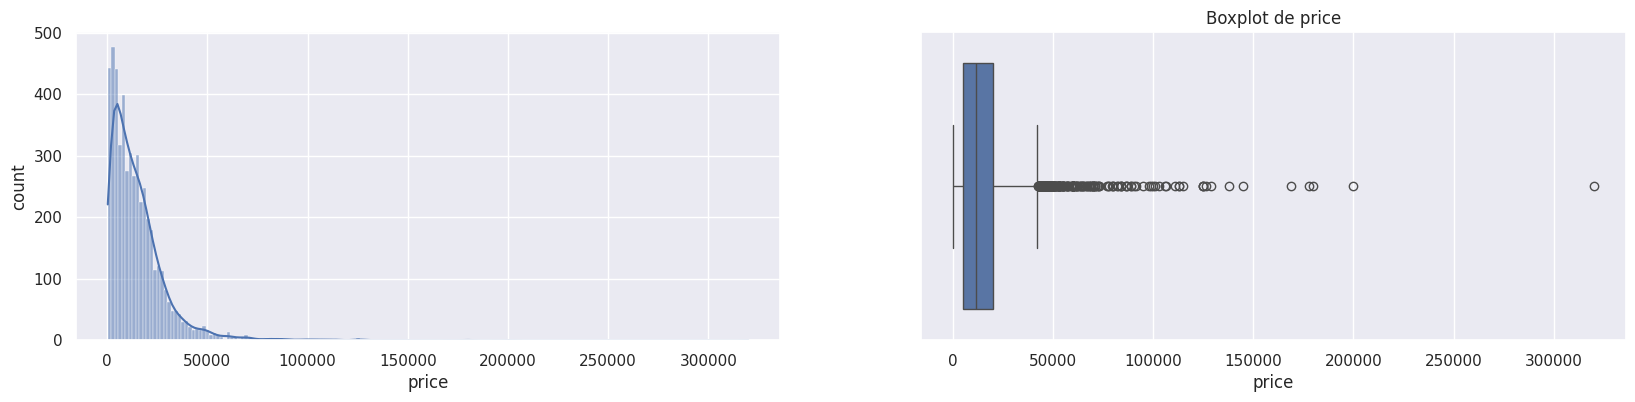

price_financed
Skew : 4.05


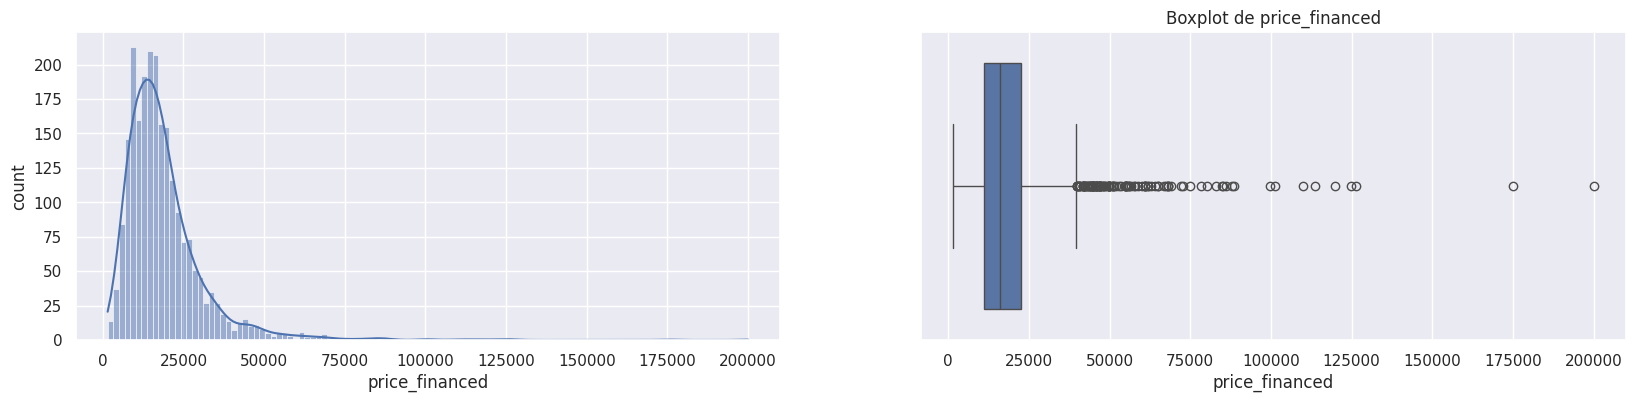

year
Skew : -0.99


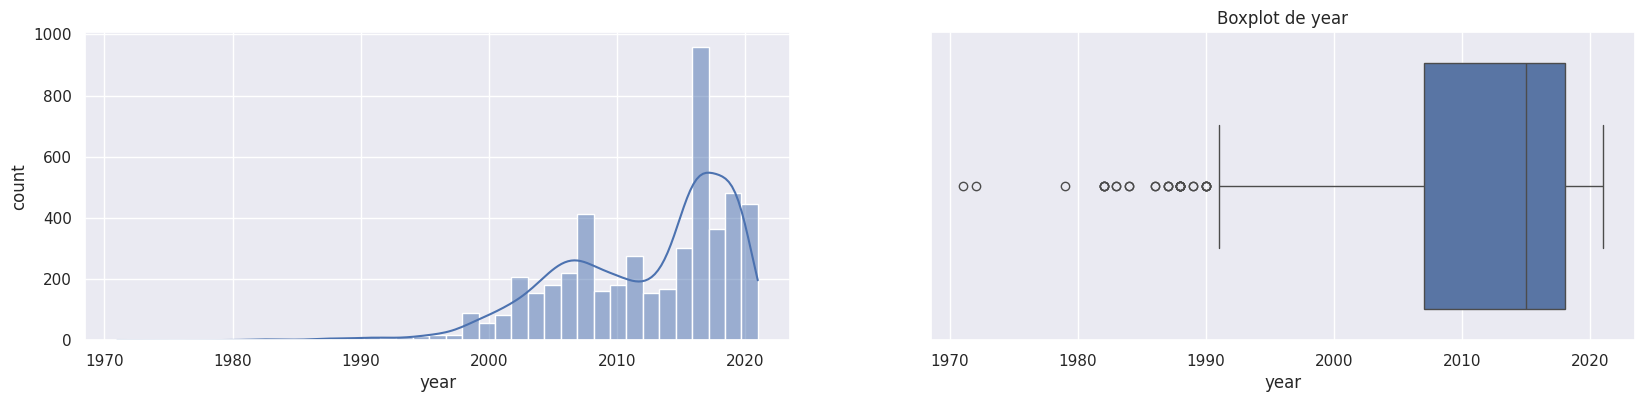

kms
Skew : 2.18


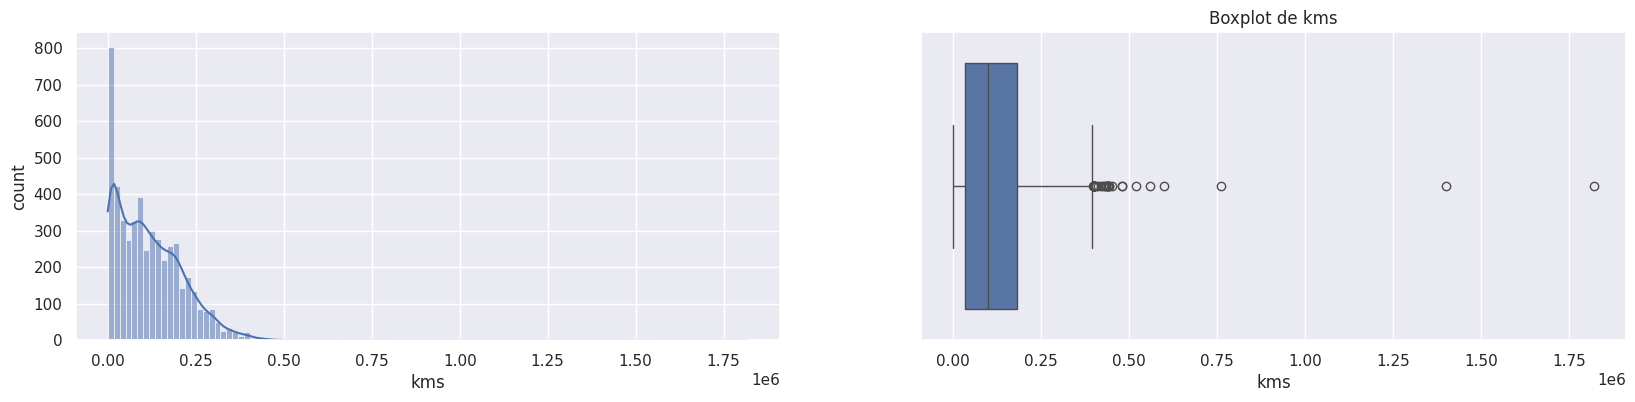

power
Skew : 2.72


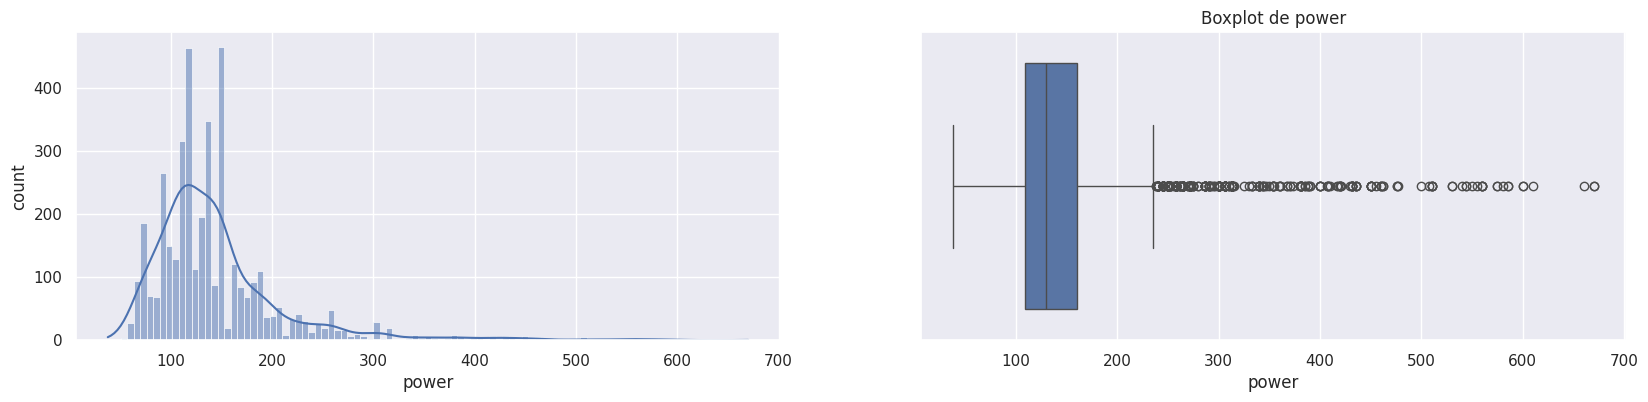

doors
Skew : -1.62


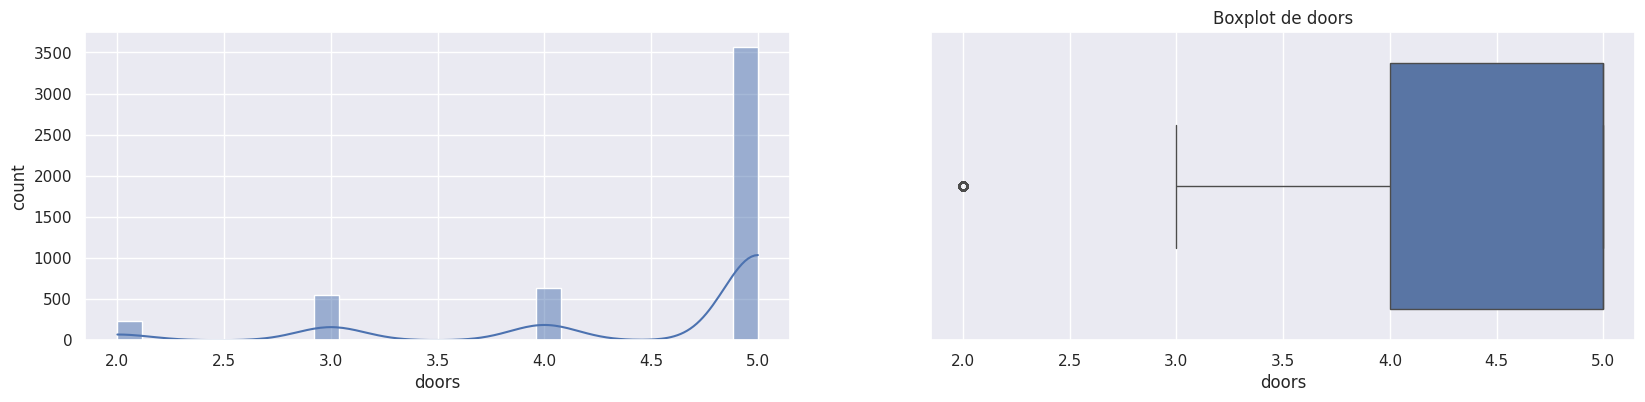

car_age
Skew : 0.99


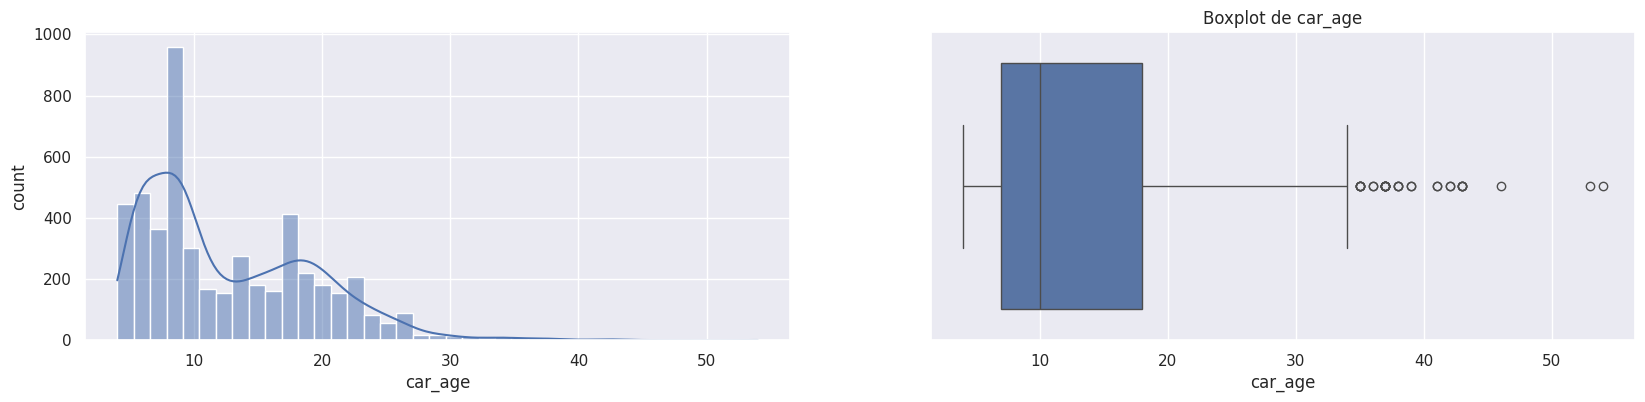

In [198]:
# Obtenim els estadístics decriptius de les columne numèriques
desc = cars[num_cols].describe().T  # transposat per accedir fàcil


for col in cars_num_cols:
    print(col)
    print('Skew :', round(cars[col].skew(), 2))
    plt.figure(figsize = (20, 4))
    plt.subplot(1, 2, 1)
    #cars[col].hist(grid=False)
    sns.histplot(data=cars, x=col, kde=True)
    plt.ylabel('count')

    #DEFINIM EL SUBPLOT (BOXPLOT)
    plt.subplot(1, 2, 2)
    ax = sns.boxplot(x=cars[col])
    ax.set_title(f"Boxplot de {col}")


    plt.show()

## Anàlisi Univariable - Dades Categòriques

In [189]:
for col in cars_cat_cols:

  counts = cars[col].value_counts()

  percent = cars[col].value_counts(normalize=True) * 100

  # Taula de recomptes i percentatges
  summary_table = pd.DataFrame({
      "Recompte": counts,
      "Percentatge": percent.round(1).astype(str) + "%"
  })

  print(summary_table)

               Recompte Percentatge
make                               
VOLKSWAGEN          497        9.9%
BMW                 462        9.2%
MERCEDES-BENZ       404        8.1%
AUDI                351        7.0%
RENAULT             346        6.9%
PEUGEOT             342        6.8%
FORD                306        6.1%
OPEL                298        6.0%
CITROEN             288        5.8%
SEAT                258        5.2%
TOYOTA              156        3.1%
NISSAN              143        2.9%
FIAT                124        2.5%
HYUNDAI             106        2.1%
KIA                  96        1.9%
VOLVO                89        1.8%
SKODA                70        1.4%
LAND-ROVER           67        1.3%
MINI                 66        1.3%
MAZDA                54        1.1%
HONDA                47        0.9%
PORSCHE              42        0.8%
MITSUBISHI           37        0.7%
JAGUAR               36        0.7%
ALFA ROMEO           33        0.7%
SUZUKI               29     

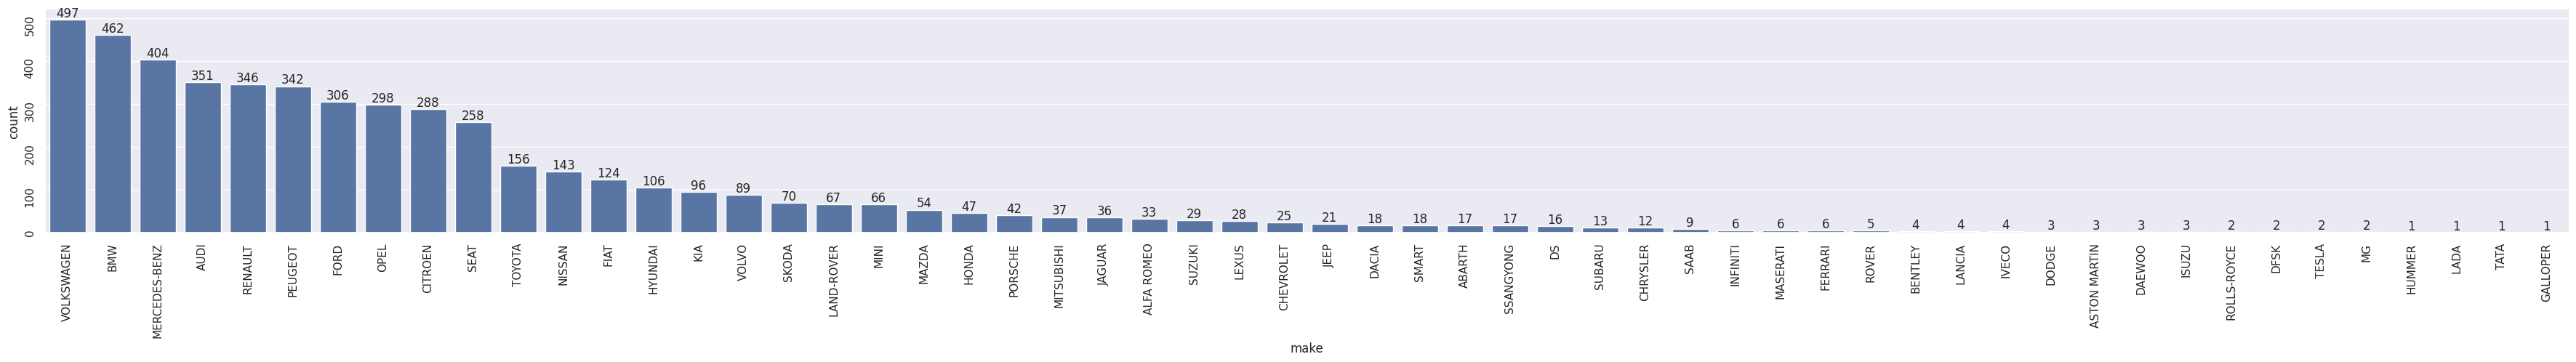

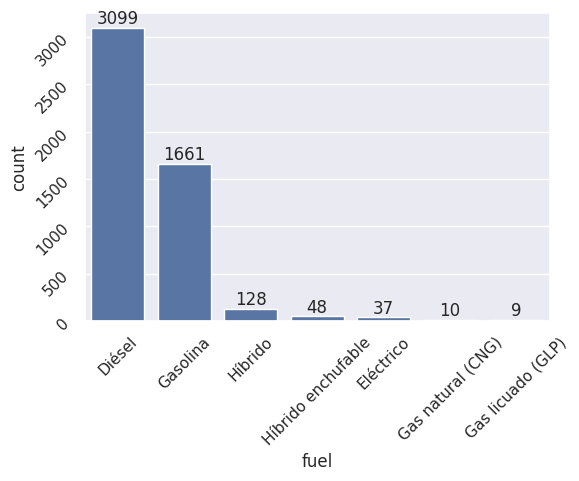

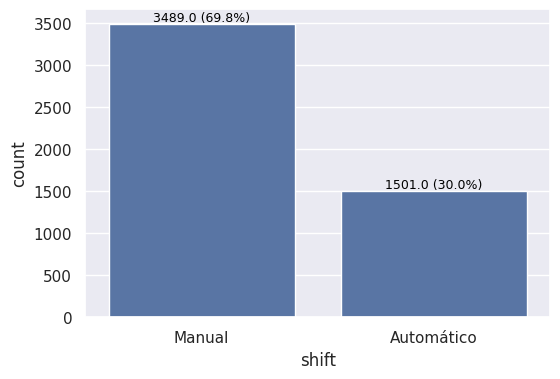

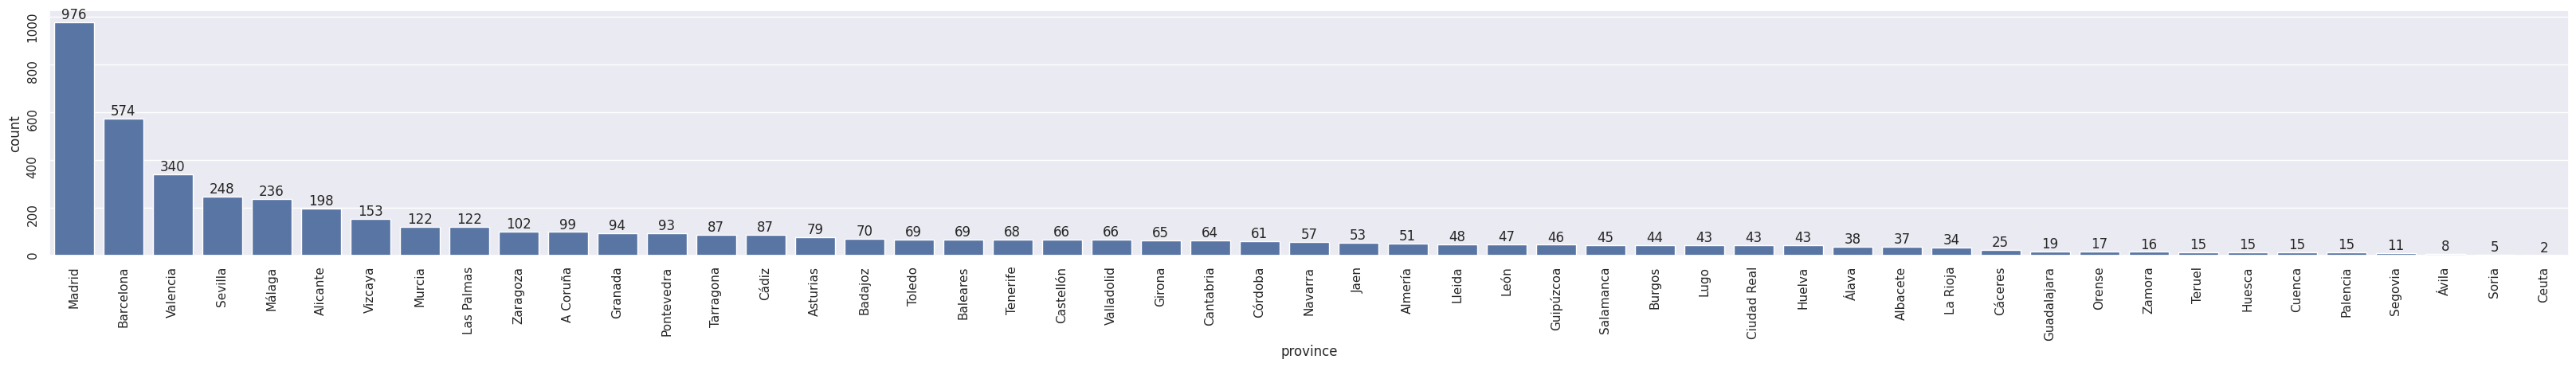

In [190]:
#Nom mostrem totes les dades categòriques perquè per exempel, model, versió o color tenen moltíssims valors únics.
cars_cat_cols = ['make','fuel','shift','province']

for col in cars_cat_cols:
    # Comptem quantes categories té la columna
    n_cat = cars[col].nunique()

    # Escalem l’amplada en funció del nombre de categories
    width = max(6, n_cat * 0.8)   # mínim 6, però creix amb les categories
    height = 4                    # alçada fixa

    plt.figure(figsize=(width, height))


    ax = sns.countplot(x=cars[col], order=cars[col].value_counts().index)
    #ax.set_title(f"{col}")
    if(4 <= n_cat <= 15):
      ax.bar_label(ax.containers[0]) #Mostrem la quantiat al damunt de cada barra
      ax.tick_params(labelrotation=45)
    elif n_cat>15:
      ax.bar_label(ax.containers[0]) #Mostrem la quantiat al damunt de cada barra
      ax.tick_params(labelrotation=90)
    else:
      total = len(cars[col])
      for p in ax.patches:
        count = p.get_height()
        percentage = 100 * count / total
        ax.annotate(f'{count} ({percentage:.1f}%)',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom',
                  fontsize=9, color="black")





    plt.show()

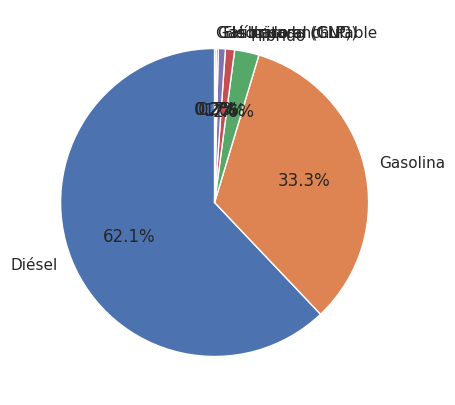

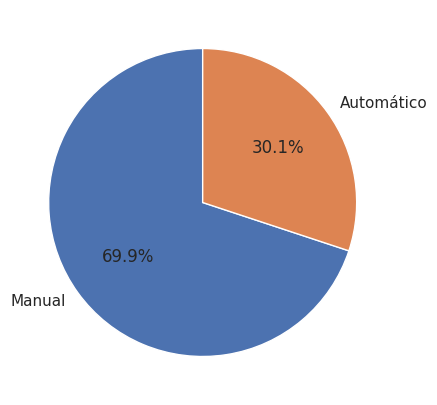

In [196]:


#Nom mostrem totes les dades categòriques perquè per exempel, model, versió o color tenen moltíssims valors únics.
cols_piechart = ['fuel','shift']

for col in cols_piechart:
  counts = cars[col].value_counts()

  plt.figure(figsize=(5,5))
  plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        startangle=90, )

  #plt.title("Distribució per sexe")
  plt.show()

## Anàlisi automàtic



In [192]:
#!pip install ydata_profiling

In [197]:
import pandas as pd
from ydata_profiling import ProfileReport
import seaborn as sns

# 2. Carregar dades (exemple Titanic)
#df = sns.load_dataset("titanic")
df = cars.copy()

# 3. Informe complet
profile = ProfileReport(
    df,
    title="EDA Report - Titanic Dataset",
    explorative=True
)

# 4. Exportar a HTML
#profile.to_file("eda_titanic.html")
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

Llicència
===================================
Autor: Robert Ventura

Aquest material s'ha elaborat gràcies a material previ de:
* [Joan Garriga](https://github.com/jgarriga65)

[![](http://i.creativecommons.org/l/by-sa/4.0/88x31.png)](http://creativecommons.org/licenses/by-sa/4.0/)

Pots utilitzar lliurament aquest material, amb les següents condicions:

* Atribuir l'autoria d'aquest repositori.
* Si l'utilitzes i fas canvis, has de alliber-lo també sota la mateixa llicència.
